# Analisi CST Multi-Ratio (Replica Cella 3)

Notebook per analizzare `Real.txt` e `Im.txt` con la stessa logica della cella 3, scegliendo quale parametro scansionare tra `RatioA`, `RatioB`, `RatioGap`.

## 1) Import librerie e configurazione cartella dati

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ipywidgets e' opzionale: se non installato, il notebook funziona comunque.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# Percorso dati
cartella = Path("SIC_P_10um/n_3")
file_re = cartella / "Real.txt"
file_im = cartella / "Im.txt"

if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")
if not file_re.exists() or not file_im.exists():
    raise FileNotFoundError(f"File mancanti: {file_re} oppure {file_im}")

# Costanti fisiche (coerenti con logica cella 3)
beta = 0.01459
Lam = 10.0
lambda_beta = Lam * beta
E0_const = 1.0

## 2) Parser CST unico con chiave variabile (`RatioA`, `RatioB`, `RatioGap`)

In [2]:
def parse_parameters_line(line: str):
    """Estrae i parametri dal blocco #Parameters in un dizionario {chiave: valore_float}."""
    m = re.search(r"#Parameters\s*=\s*\{(.*)\}", line)
    if not m:
        return {}

    body = m.group(1)
    params = {}
    for item in body.split(";"):
        item = item.strip()
        if not item or "=" not in item:
            continue
        k, v = item.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            params[k] = float(v)
        except ValueError:
            continue
    return params


def parse_cst_blocks(path: Path, varying_param: str, fixed_params=None, n_target=None, tol=1e-12):
    """
    Parse file CST con blocchi ripetuti.
    Restituisce dict: blocks[var_value] = {"x": array, "y": array, "params": dict}.

    Filtri opzionali:
    - fixed_params: dict con parametri da tenere fissi (es. {"RatioB":0.5, "RatioGap":0.5})
    - n_target: armonica da selezionare
    """
    if fixed_params is None:
        fixed_params = {}

    blocks = {}
    active = False
    current_value = None
    current_x = []
    current_y = []
    current_params = None

    def flush_block():
        if active and current_value is not None and current_x:
            blocks[current_value] = {
                "x": np.array(current_x, dtype=float),
                "y": np.array(current_y, dtype=float),
                "params": current_params,
            }

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                flush_block()

                params = parse_parameters_line(line)
                active = True
                current_x = []
                current_y = []
                current_params = params
                current_value = None

                if varying_param not in params:
                    active = False
                    continue

                if n_target is not None:
                    n_val = params.get("n")
                    if n_val is None or abs(n_val - float(n_target)) > tol:
                        active = False
                        continue

                ok = True
                for k, v in fixed_params.items():
                    pv = params.get(k)
                    if pv is None or abs(pv - float(v)) > tol:
                        ok = False
                        break
                if not ok:
                    active = False
                    continue

                current_value = float(params[varying_param])
                continue

            if line.startswith("#"):
                continue

            if not active:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    flush_block()
    return blocks

## 3) Selettore parametro da scandire (input o widget Jupyter)

In [14]:
allowed_params = ["RatioA", "RatioB", "RatioGap"]

# Selezione manuale (fallback universale)
param_name = "RatioGap"
n_target = 3

# Default: tengo fissi gli altri due ratio a 0.5 (modificabili)
default_fixed_values = {
    "RatioA": 0.5,
    "RatioB": 0.5,
    "RatioGap": 0.5,
}

if param_name not in allowed_params:
    raise ValueError(f"param_name non valido: {param_name}. Opzioni: {allowed_params}")

fixed_params = {
    k: default_fixed_values[k]
    for k in allowed_params
    if k != param_name
}

print(f"Parametro variabile selezionato: {param_name}")
print(f"Parametri fissi: {fixed_params}")
print(f"n_target: {n_target}")

# Widget opzionale
if HAS_WIDGETS:
    w = widgets.Dropdown(options=allowed_params, value=param_name, description="Scansione:")
    display(w)
    print("Puoi cambiare il dropdown e poi assegnare param_name = w.value prima di run_analysis().")

Parametro variabile selezionato: RatioGap
Parametri fissi: {'RatioA': 0.5, 'RatioB': 0.5}
n_target: 3


## 4-8) Allineamento, calcolo, tabella, grafici e funzione unica `run_analysis(param_name)`

Riepilogo risultati:
RatioGap=0.100  G=7.387255e-02  eta_E0=7.387255e-02  Emax=1.371813e+00  eta_Emax=5.385032e-02  phi=+155.84 deg
RatioGap=0.200  G=3.166544e-02  eta_E0=3.166544e-02  Emax=1.288544e+00  eta_Emax=2.457459e-02  phi=+155.94 deg
RatioGap=0.300  G=1.275205e-02  eta_E0=1.275205e-02  Emax=1.197448e+00  eta_Emax=1.064936e-02  phi=+156.09 deg
RatioGap=0.400  G=4.988660e-03  eta_E0=4.988660e-03  Emax=1.112190e+00  eta_Emax=4.485439e-03  phi=+156.29 deg
RatioGap=0.500  G=1.960233e-03  eta_E0=1.960233e-03  Emax=1.040149e+00  eta_Emax=1.884570e-03  phi=+156.51 deg
RatioGap=0.600  G=7.664600e-04  eta_E0=7.664600e-04  Emax=9.824357e-01  eta_Emax=7.801631e-04  phi=+156.75 deg
RatioGap=0.700  G=2.983005e-04  eta_E0=2.983005e-04  Emax=9.376298e-01  eta_Emax=3.181432e-04  phi=+157.00 deg
RatioGap=0.800  G=1.165359e-04  eta_E0=1.165359e-04  Emax=9.034885e-01  eta_Emax=1.289844e-04  phi=+157.25 deg
RatioGap=0.900  G=4.462851e-05  eta_E0=4.462851e-05  Emax=8.774721e-01  eta_Emax=5.086032e-

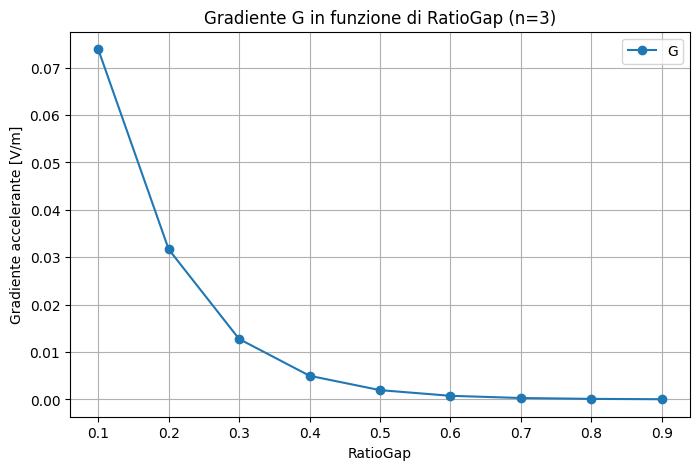

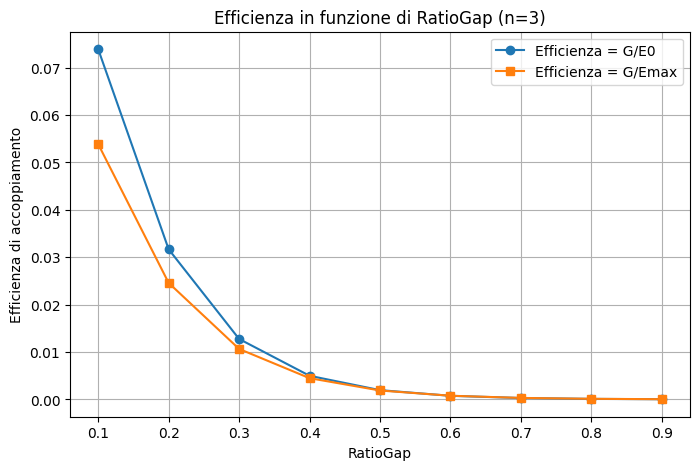

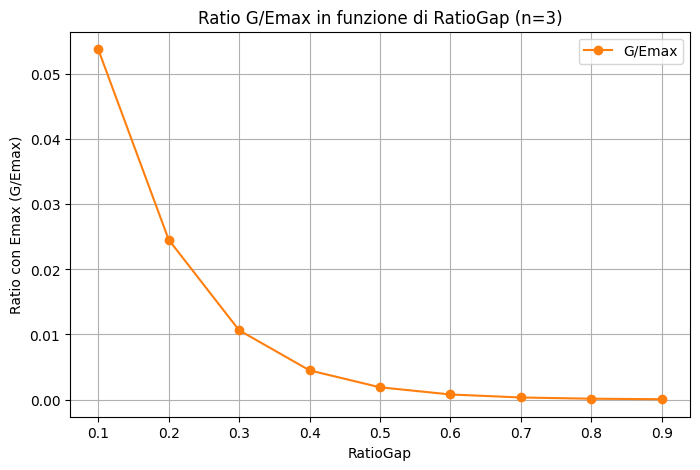

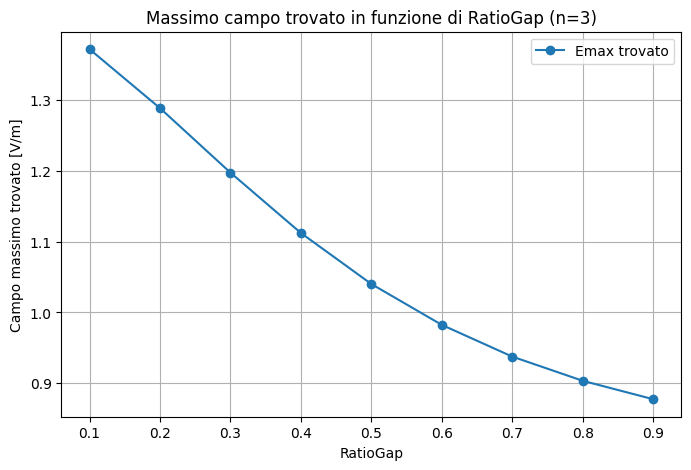

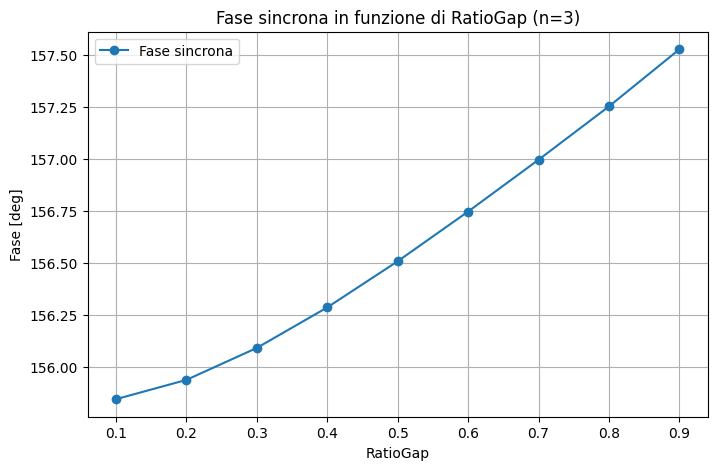

In [15]:
def run_analysis(param_name: str, fixed_params=None, n_target=3, tol=1e-12):
    """Pipeline completa: parse, allineamento, calcolo metriche, tabella e grafici."""
    allowed = ["RatioA", "RatioB", "RatioGap"]
    if param_name not in allowed:
        raise ValueError(f"param_name non valido: {param_name}. Opzioni: {allowed}")

    if fixed_params is None:
        fixed_defaults = {"RatioA": 0.5, "RatioB": 0.5, "RatioGap": 0.5}
        fixed_params = {k: fixed_defaults[k] for k in allowed if k != param_name}

    blocks_re = parse_cst_blocks(
        file_re,
        varying_param=param_name,
        fixed_params=fixed_params,
        n_target=n_target,
        tol=tol,
    )
    blocks_im = parse_cst_blocks(
        file_im,
        varying_param=param_name,
        fixed_params=fixed_params,
        n_target=n_target,
        tol=tol,
    )

    common_values = sorted(set(blocks_re.keys()) & set(blocks_im.keys()))
    if not common_values:
        raise ValueError(
            "Nessun valore comune tra Real/Im con i filtri scelti. "
            f"param_name={param_name}, fixed_params={fixed_params}, n_target={n_target}"
        )

    n_harm = int(n_target)
    lambda_p = n_harm * lambda_beta

    G = np.zeros(len(common_values))
    eta_E0 = np.zeros(len(common_values))
    eta_Emax = np.zeros(len(common_values))
    E_max = np.zeros(len(common_values))
    phi_rad = np.zeros(len(common_values))
    phi_deg = np.zeros(len(common_values))

    for i, val in enumerate(common_values):
        x_re = blocks_re[val]["x"]
        x_im = blocks_im[val]["x"]
        y_re = blocks_re[val]["y"]
        y_im = blocks_im[val]["y"]

        if len(x_re) != len(x_im) or np.max(np.abs(x_re - x_im)) > tol:
            raise ValueError(f"Asse x non allineato per {param_name}={val}")

        x = x_re
        Ex = y_re + 1j * y_im

        phase = np.exp(-1j * 2 * np.pi * n_harm * x / lambda_p)
        L = x[-1] - x[0]
        complex_grad = np.trapezoid(Ex * phase, x) / L

        G[i] = np.abs(complex_grad)
        phi_rad[i] = np.angle(complex_grad)
        phi_deg[i] = np.degrees(phi_rad[i])

        E_max[i] = np.max(np.abs(Ex))
        eta_E0[i] = G[i] / E0_const
        eta_Emax[i] = G[i] / E_max[i]

    # Tabella risultati ordinata
    rows = []
    for i, val in enumerate(common_values):
        rows.append(
            {
                param_name: float(val),
                "G": float(G[i]),
                "phi_deg": float(phi_deg[i]),
                "E_max": float(E_max[i]),
                "eta_E0": float(eta_E0[i]),
                "eta_Emax": float(eta_Emax[i]),
            }
        )

    print("Riepilogo risultati:")
    for r in rows:
        print(
            f"{param_name}={r[param_name]:.3f}  "
            f"G={r['G']:.6e}  "
            f"eta_E0={r['eta_E0']:.6e}  "
            f"Emax={r['E_max']:.6e}  "
            f"eta_Emax={r['eta_Emax']:.6e}  "
            f"phi={r['phi_deg']:+.2f} deg"
        )

    # Grafico 1: G
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, G, marker="o", label="G")
    plt.xlabel(param_name)
    plt.ylabel("Gradiente accelerante [V/m]")
    plt.title(f"Gradiente G in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_G_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 2: Efficienze
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, eta_E0, marker="o", label="Efficienza = G/E0")
    plt.plot(common_values, eta_Emax, marker="s", label="Efficienza = G/Emax")
    plt.xlabel(param_name)
    plt.ylabel("Efficienza di accoppiamento")
    plt.title(f"Efficienza in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_efficiency_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 3: solo G/Emax
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, eta_Emax, marker="o", color="tab:orange", label="G/Emax")
    plt.xlabel(param_name)
    plt.ylabel("Ratio con Emax (G/Emax)")
    plt.title(f"Ratio G/Emax in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_ratio_Emax_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 4: Emax
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, E_max, marker="o", label="Emax trovato")
    plt.xlabel(param_name)
    plt.ylabel("Campo massimo trovato [V/m]")
    plt.title(f"Massimo campo trovato in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
   # plt.savefig(cartella / f"{param_name}_Emax_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 5: fase
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, phi_deg, marker="o", label="Fase sincrona")
    plt.xlabel(param_name)
    plt.ylabel("Fase [deg]")
    plt.title(f"Fase sincrona in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    #plt.savefig(cartella / f"{param_name}_phi_vs_{param_name}_n{n_harm}.png")
    plt.show()

    return {
        "param_name": param_name,
        "fixed_params": fixed_params,
        "n_target": n_harm,
        "x": np.array(common_values, dtype=float),
        "G": G,
        "eta_E0": eta_E0,
        "eta_Emax": eta_Emax,
        "E_max": E_max,
        "phi_deg": phi_deg,
        "rows": rows,
    }


# Esempio rapido di esecuzione
result = run_analysis(param_name=param_name, fixed_params=fixed_params, n_target=n_target)